<a href="https://colab.research.google.com/github/jahnavimidde/Deep_learning/blob/main/DL11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3388 - val_loss: 0.2715
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2678 - val_loss: 0.2653
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.2648 - val_loss: 0.2640
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2639 - val_loss: 0.2634
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2633 - val_loss: 0.2630
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2632 - val_loss: 0.2628
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2630 - val_loss: 0.2618
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2594 - val_los

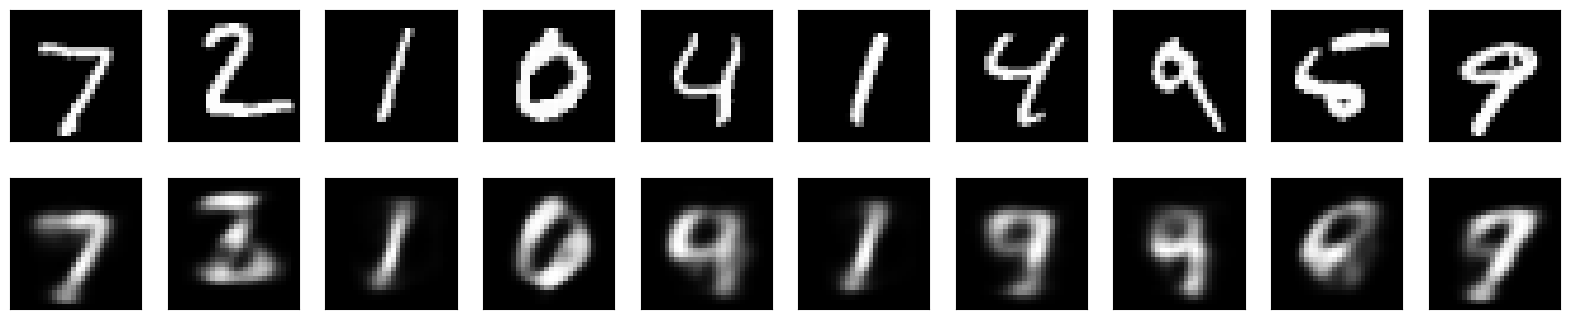

In [1]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

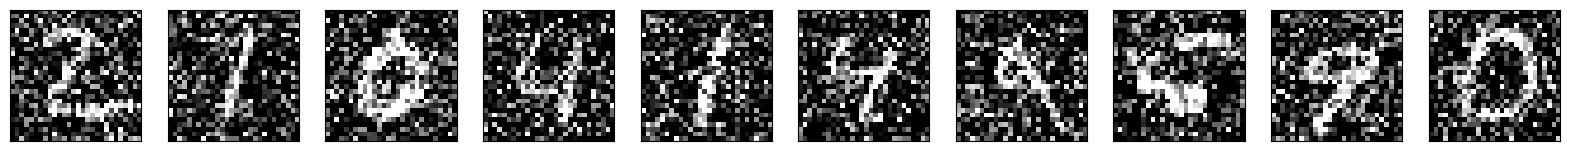

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 279ms/step - loss: 0.1596 - val_loss: 0.1168
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 279ms/step - loss: 0.1127 - val_loss: 0.1079
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 287ms/step - loss: 0.1067 - val_loss: 0.1046
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 274ms/step - loss: 0.1038 - val_loss: 0.1028
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 287ms/step - loss: 0.1019 - val_loss: 0.1003
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 286ms/step - loss: 0.1006 - val_loss: 0.0992
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 279ms/step - loss: 0.0997 - val_loss: 0.0985
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 285ms/step - loss: 0.0989 - val_loss: 0.0979
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 277ms/step - loss: 0.0984 - val_loss: 0.0973
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 272ms/step - loss: 0.0978 - val_loss: 0.0970
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step


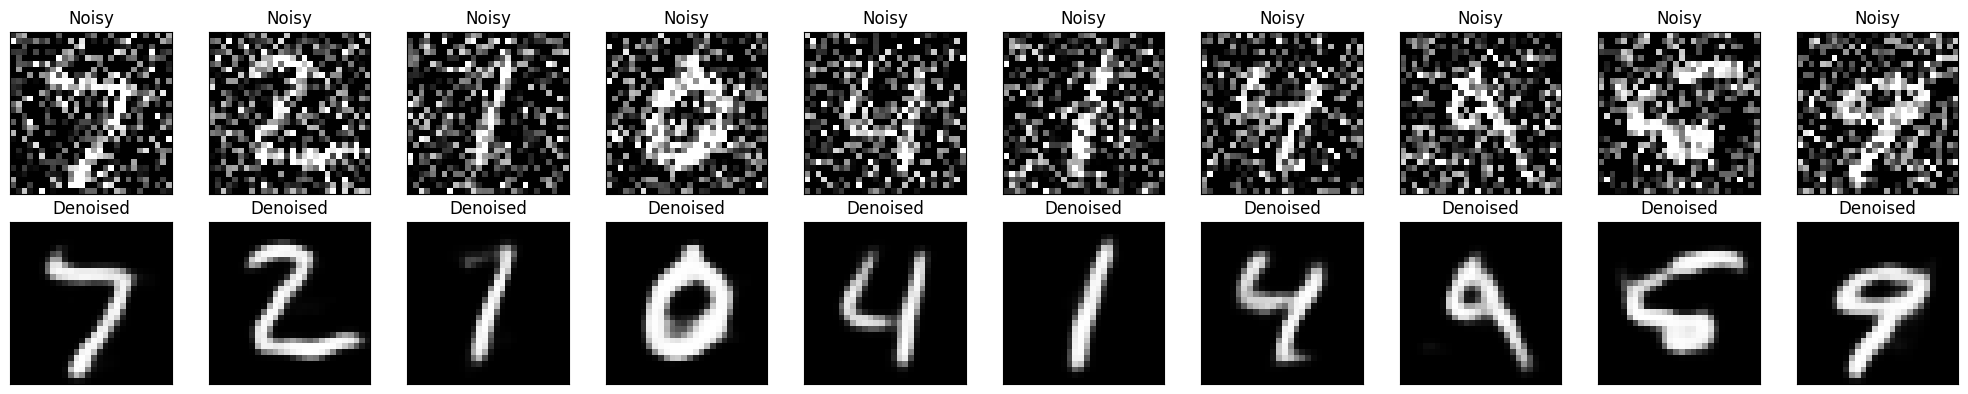

In [2]:
import keras
from keras import layers
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
from keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


n = 10
plt.figure(figsize=(20, 2))
for i in range(1, n + 1):
    ax = plt.subplot(1, n, i)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


input_img = keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# At this point the representation is (7, 7, 32)

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


autoencoder.fit(x_train_noisy, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test),
                callbacks=[TensorBoard(log_dir='/tmp/tb', histogram_freq=0, write_graph=False)])



# Predict the denoised images
decoded_imgs = autoencoder.predict(x_test_noisy)

# Display the original noisy and reconstructed (denoised) images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display noisy input
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.title("Noisy")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed output
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.title("Denoised")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()







In [6]:
# Undercomplete Autoencoder (Compression)

encoding_dim = 32  # smaller than 784 → compression

# Reshape x_train and x_test for this autoencoder
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)
decoded = Dense(input_dim, activation='sigmoid')(encoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder.fit(x_train_flat, x_train_flat,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat))

decoded_imgs_under = autoencoder.predict(x_test_flat)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3380 - val_loss: 0.2716
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2678 - val_loss: 0.2654
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2648 - val_loss: 0.2639
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2639 - val_loss: 0.2634
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2635 - val_loss: 0.2632
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.2633 - val_loss: 0.2629
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2631 - val_loss: 0.2628
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.2629 - val_loss: 0.2618
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2595 - val_loss: 0.2571
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# 1. Load and Prepare Data if not already loaded
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Define input_dim here
input_dim = 784  # 28x28 images

# Overcomplete Autoencoder (No compression)

encoding_dim = 1024  # larger than 784 → overcomplete

# Reshape x_train and x_test for this autoencoder
x_train_flat = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test_flat = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

input_layer = Input(shape=(input_dim,))
encoded = Dense(1024, activation='relu')(input_layer)
encoded = Dense(512, activation='relu')(encoded)

decoded = Dense(1024, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

autoencoder_over = Model(input_layer, decoded)

autoencoder_over.compile(optimizer='adam', loss='binary_crossentropy')

autoencoder_over.fit(x_train_flat, x_train_flat,
                     epochs=50,
                     batch_size=256,
                     shuffle=True,
                     validation_data=(x_test_flat, x_test_flat))

decoded_imgs_over = autoencoder_over.predict(x_test_flat)

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - loss: 0.1450 - val_loss: 0.0888
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 24s 102ms/step - loss: 0.0815 - val_loss: 0.0761
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - loss: 0.0744 - val_loss: 0.0722
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 24s 103ms/step - loss: 0.0716 - val_loss: 0.0703
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - loss: 0.0700 - val_loss: 0.0690
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - loss: 0.0688 - val_loss: 0.0683
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - loss: 0.0680 - val_loss: 0.0675
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - loss: 0.0674 - val_loss: 0.0670
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - loss: 0.0670 - val_loss: 0.0673
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 41s 104ms/step - loss: 0.0666 - val_loss: 0.0663
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - loss: 0.0662 - val_loss: 0.0659
Epoch 12/50
235/235 

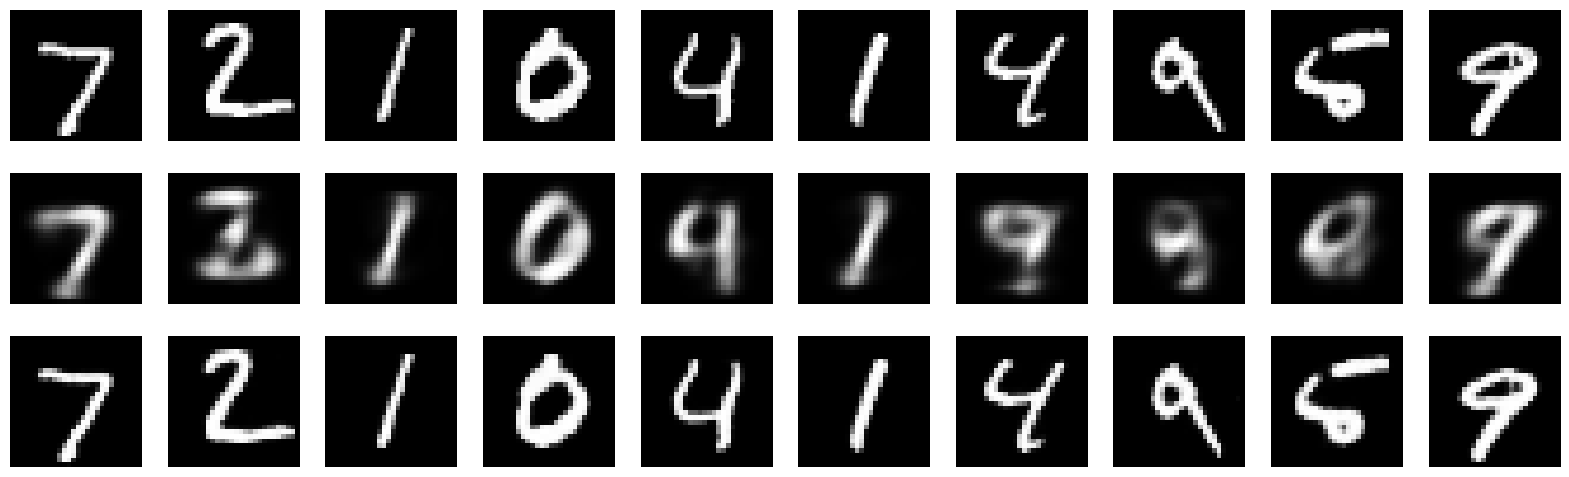

In [8]:
import matplotlib.pyplot as plt
import numpy as np

n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.axis('off')

    # Undercomplete
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs_under[i].reshape(28, 28))
    plt.gray()
    ax.axis('off')

    # Overcomplete
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs_over[i].reshape(28, 28))
    plt.gray()
    ax.axis('off')

plt.show()

In [9]:
from tensorflow.keras import regularizers

# Encoder with L1 Regularization
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(32, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(encoded)

In [11]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers
import numpy as np

input_layer = Input(shape=(784,))

encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(32, activation='relu',
                activity_regularizer=regularizers.l1(1e-5))(encoded)

decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Use the flattened data (x_train_flat, x_test_flat) from previous cells
autoencoder.fit(x_train_flat, x_train_flat,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test_flat, x_test_flat))

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.3045 - val_loss: 0.2158
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1942 - val_loss: 0.1801
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.1753 - val_loss: 0.1694
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1675 - val_loss: 0.1633
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1624 - val_loss: 0.1587
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1581 - val_loss: 0.1548
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1545 - val_loss: 0.1517
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1519 - val_loss: 0.1498
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.1498 - val_loss: 0.1474
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1480 - val_loss: 0.1462
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1466 - val_loss: 0.1445
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 